# 📊 Fitly Customer Churn Analysis

# Project Overview

Fit.ly Tech is a subscription-based fitness app that offers users access to workouts, articles, and videos across different plan tiers (Free, Basic, Pro, and Enterprise). Over the past two quarters, the company has experienced a noticeable increase in customer churn, which poses a significant challenge given the rising costs of acquiring new users.

To address this issue, leadership has asked for a comprehensive churn analysis that identifies the key drivers behind customer cancellations and provides actionable recommendations to improve retention.

For this project, we are working with three datasets:

Account Information: Customer details including subscription plan, price paid, and churn status.

User Activity: Logs of user engagement such as watching videos, reading articles, tracking workouts, and sharing workouts.

Customer Support: Records of support tickets, resolution times, and channels (partially restricted in this case).

Together, these datasets provide a holistic view of customer behavior, engagement, and support interactions. By validating and analyzing this data, aiming to uncover patterns that explain churn and define metrics that leadership can monitor to guide retention strategies

# Business Goals:

- find what driving churn?

# Data validation:
1. user_activity, this dataset has 3 columns (+3 i added) and 445 rows i have validated all the   variables and made some changes,even after validation it has 445 rows no rows are droped.
- event_time: changed data type into datetime.
- user_id: numeric values without missing values, same as the description. No cleaning is needed.
- event_type: same 4 valid categories without missing values, same as the description. No cleaning is needed.
 
2.account_info, this dataset has 6 columns (+2 column i added) and 400 rows i have validated all the variables and made some changes, even after validation there is 400 rows no rows are droped.
-   customer_id: strip the 'C' from it and change data type to integer.
- email: standerdized and same as the description. No cleaning is needed.
- state: 50 US states without missing values, same as the description. No cleaning is needed.
- plan: 4 categories after validation without missing values, same as the description. No cleaning is needed.
- plan_list_price: numeric values without missing values, same as the description. No cleaning is needed.
- churn_status: fill the Nan with place holder representing (non churn).
  
3.customer_support, this dataset has 7 columns (+6 columns i added) and 918 rows i have validated all variables and made some changes, even after validation there is 918 rows no rows are droped.
-   ticket_time: convert it to datetime data type.
- user_id: numeric values without missing values, same as the description. No cleaning is needed.
- channel: replace '-' with 'Unknown' as place holder, 4 channels. No cleaning is needed.
- topic: 4 categories without missing values, same as the description. No cleaning is needed.
- resolution_time_hour: numeric values without missing values, same as the description. No cleaning is needed.
- state: maping, converting (0 & 1) to 'Open' & 'Close'.      

In [2]:
# initial setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Data inspection**

In [3]:
# user activity csv
user = pd.read_csv('da_fitly_user_activity.csv')
user.head()

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


In [4]:
# user activity
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  445 non-null    object
 1   user_id     445 non-null    int64 
 2   event_type  445 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.6+ KB


In [5]:
# null values in user
print(user.isnull().sum())

event_time    0
user_id       0
event_type    0
dtype: int64


In [6]:
# duplicates in user
print('duplicates:', user.duplicated().sum())

duplicates: 0


In [7]:
# customer support csv
customer = pd.read_csv("da_fitly_customer_support.csv")
customer.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN


In [8]:
# customer support
# description for numeric values
print(customer.describe())

            user_id  resolution_time_hours       state
count    918.000000             918.000000  918.000000
mean   10201.985839              10.391362    0.549020
std      116.048475               7.079888    0.497863
min    10000.000000               0.520000    0.000000
25%    10103.000000               5.112500    0.000000
50%    10205.500000               9.040000    1.000000
75%    10302.750000              13.137500    1.000000
max    10399.000000              32.460000    1.000000


In [9]:
# information of customer
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    object 
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    object 
 3   topic                  918 non-null    object 
 4   resolution_time_hours  918 non-null    float64
 5   state                  918 non-null    int64  
 6   comments               46 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 50.3+ KB


In [10]:
# null in costomer
print(customer.isnull().sum())

ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64


In [11]:
# duplicates in customer
print('duplicates:', customer.duplicated().sum())

duplicates: 0


In [12]:
# account info csv
account = pd.read_csv("da_fitly_account_info.csv")
account.head()

,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,C10003,user10003@example.com,Michigan,Free,0,NaN
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN


In [13]:
# account info
# describe numeric values
print(account.describe())

       plan_list_price
count       400.000000
mean         43.965000
std          45.263348
min           0.000000
25%           0.000000
50%          26.000000
75%          77.250000
max         148.000000


In [14]:
# account csv information
account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB


In [15]:
# null in account
print(account.isnull().sum())

customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64


In [16]:
# duplicates in account
print('duplicates:', account.duplicated().sum())

duplicates: 0


**Data validation and cleaning**

_**user activity csv data validation and cleaning**_

In [17]:
# user activity
# change event time column into timestamp
user['event_time'] = pd.to_datetime(user['event_time'])

In [18]:
# Extract components from datetime
user['date_user'] = user['event_time'].dt.date 
user['month_user'] = user['event_time'].dt.month 
user['day_of_week_user'] = user['event_time'].dt.day_name()

In [19]:
# ckecking for any outlier in event time
print("event time outlier:")
print('Max date:', user['event_time'].max())
print('Min date:', user['event_time'].min())

event time outlier:
Max date: 2025-12-01 21:12:13.342817
Min date: 2025-06-05 10:14:53.039663


In [20]:
# Total count user id
total_count = user["user_id"].count()

# Unique count of user id
unique_count = user["user_id"].nunique()

# Compare
print("Total accounts:", total_count)
print("Unique accounts:", unique_count)
print("Duplicates exist:", total_count != unique_count)

Total accounts: 445
Unique accounts: 246
Duplicates exist: True


In [21]:
# count categorys in event type
print("count event types:")
print(user['event_type'].value_counts())

count event types:
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: event_type, dtype: int64


In [22]:
# Validate event types 
valid_events = ["watch_video", "read_article", "track_workout", "share_workout"] 
invalid_events = user[~user["event_type"].isin(valid_events)] 
print("\nInvalid event types:\n", invalid_events)


Invalid event types:
 Empty DataFrame
Columns: [event_time, user_id, event_type, date_user, month_user, day_of_week_user]
Index: []


_account info csv data validation and cleaning_

In [23]:
# account info validation and cleaning
# Extract numeric ID from customer_id for easier merging
account['user_id'] = account['customer_id'].str.extract('(\d+)').astype(int)

In [24]:
# check if customer id are duplicte (which is not allowed)
print("customer_id duplicates:")
print(account['customer_id'].duplicated().sum())

customer_id duplicates:
0


In [25]:
# Check if all IDs start with "C" 
all_start_with_C = account["customer_id"].str.startswith("C").all() 
print("Do all IDs start with 'C'? ->", all_start_with_C)

Do all IDs start with 'C'? -> True


In [26]:
# checking for upper case letters in email
upper = account[account['email'].apply(lambda x: any(ch.isupper() for ch in x))]
print(upper)

Empty DataFrame
Columns: [customer_id, email, state, plan, plan_list_price, churn_status, user_id]
Index: []


In [27]:
# checking for email duplicates
print(account['email'].duplicated().sum())

0


In [28]:
# Regex pattern for email validation 
pattern = r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$' 
# Check which emails are valid
valid_emails = account["email"].str.match(pattern) 
all_valid = valid_emails.all()
print("Do all emails follow the email format? ->", all_valid)

Do all emails follow the email format? -> True


In [29]:
#count number of states
print('count states:')
print('states =', account['state'].nunique())

count states:
states = 50


In [30]:
# check if they are in US and are normalized
print(account["state"].unique())
account["state"] = account["state"].str.title()

['New Jersey' 'Louisiana' 'Oklahoma' 'Michigan' 'Texas' 'Ohio' 'Kentucky'
 'North Carolina' 'Alaska' 'Virginia' 'Kansas' 'Arizona' 'Idaho'
 'Connecticut' 'Colorado' 'Rhode Island' 'Maine' 'Wisconsin' 'Vermont'
 'Florida' 'Delaware' 'New York' 'Montana' 'Missouri' 'West Virginia'
 'New Mexico' 'Iowa' 'North Dakota' 'Hawaii' 'Nebraska' 'South Dakota'
 'Utah' 'Washington' 'Pennsylvania' 'Nevada' 'Arkansas' 'Illinois'
 'Wyoming' 'California' 'Tennessee' 'Minnesota' 'Maryland' 'Massachusetts'
 'Mississippi' 'South Carolina' 'Oregon' 'Georgia' 'Indiana' 'Alabama'
 'New Hampshire']


In [31]:
#Validate plan categories 
valid_plans = ["Free", "Basic", "Pro", "Enterprise"] 
accounts = account[~account["plan"].isin(valid_plans)]
print(accounts)

Empty DataFrame
Columns: [customer_id, email, state, plan, plan_list_price, churn_status, user_id]
Index: []


In [32]:
# plan distribution
print(f"Plan distribution:\n{account['plan'].value_counts()}")

Plan distribution:
Basic         118
Free          105
Enterprise     92
Pro            85
Name: plan, dtype: int64


In [33]:
# Check plan prices by plan type
print("\nPlan prices by plan type:")
print(account.groupby('plan')['plan_list_price'].describe())


Plan prices by plan type:
            count        mean        std   min   25%    50%    75%    max
plan                                                                     
Basic       118.0   19.872881   5.914702  10.0  15.0   20.0   24.0   30.0
Enterprise   92.0  116.010870  20.532737  81.0  96.5  119.0  134.0  148.0
Free        105.0    0.000000   0.000000   0.0   0.0    0.0    0.0    0.0
Pro          85.0   53.741176  14.595460  32.0  42.0   53.0   64.0   80.0


In [34]:
# Ensure plan_list_price is non-negative 
invalid_prices = account[account["plan_list_price"] < 0]
print("\nInvalid price entries:") 
print(invalid_prices)


Invalid price entries:
Empty DataFrame
Columns: [customer_id, email, state, plan, plan_list_price, churn_status, user_id]
Index: []


In [35]:
# find out if plan free has a price
x = account.groupby('plan')['plan_list_price'].unique().reset_index()
print(x)

         plan                                    plan_list_price
0       Basic  [22, 24, 19, 10, 16, 30, 28, 12, 29, 17, 20, 2...
1  Enterprise  [105, 119, 114, 87, 93, 104, 110, 138, 100, 90...
2        Free                                                [0]
3         Pro  [51, 57, 64, 32, 43, 42, 53, 33, 79, 49, 61, 7...


_**custommer sapport csv data validation**_

In [36]:
# convert ticker_time from object to datetime value
customer['ticket_time'] = pd.to_datetime(customer['ticket_time'])

# Extract components
customer['date'] = customer['ticket_time'].dt.date
customer['month'] = customer['ticket_time'].dt.month
customer['day_of_week'] = customer['ticket_time'].dt.day_name()

In [37]:
# Handle missing channels (replace with 'unknown')
customer['channel'] = customer['channel'].replace('-', 'unknown')

#Validate channel categories
print('customer sapport channel:')
print(customer['channel'].unique())

customer sapport channel:
['chat' 'phone' 'unknown' 'email']


In [38]:
#count the number of channels
print('channel counts:')
print(customer['channel'].value_counts())

channel counts:
email      298
chat       294
phone      287
unknown     39
Name: channel, dtype: int64


In [39]:
# find unique topics
print('customer sapport topics:')
print(customer['topic'].unique())

customer sapport topics:
['technical' 'account' 'other' 'billing']


In [40]:
#count number of unique topics
print('count topics:')
print(customer['topic'].value_counts())

count topics:
billing      239
other        228
technical    226
account      225
Name: topic, dtype: int64


In [41]:
# Check resolution time statistics
print(f"\nResolution time statistics (hours):")
print(customer['resolution_time_hours'].describe())


Resolution time statistics (hours):
count    918.000000
mean      10.391362
std        7.079888
min        0.520000
25%        5.112500
50%        9.040000
75%       13.137500
max       32.460000
Name: resolution_time_hours, dtype: float64


In [42]:
# unique states
print(customer['state'].unique())

[1 0]


In [43]:
# Map to descriptive labels 
state_map = {0: "Open", 1: "Closed"} 
customer["state_name"] = customer["state"].map(state_map)

In [44]:
# Strip whitespace 
customer['comments'] = customer['comments'].str.strip()

In [45]:
# Replace missing values with a placeholder 
customer["comments"] = customer["comments"].fillna("No comment") 

In [46]:
# Optional: normalize case (lowercase for consistency) 
customer["comment_clean"] = customer["comments"].str.lower() 

In [47]:
# Check for duplicates
duplicate_comments = customer[customer["comments"].duplicated(keep=False)] 
print("Duplicate comments:\n", duplicate_comments)

Duplicate comments:
                    ticket_time  ...                     comment_clean
0   2025-06-13 05:55:17.154573  ...                        no comment
1   2025-08-06 13:21:54.539551  ...                        no comment
2   2025-08-22 12:39:35.718663  ...  erase my data from your systems.
3   2025-06-07 02:49:46.986055  ...                        no comment
4   2025-07-25 00:24:38.945079  ...                        no comment
..                         ...  ...                               ...
913 2025-06-05 23:09:46.282238  ...                        no comment
914 2025-08-19 11:03:30.765219  ...                        no comment
915 2025-08-07 13:17:13.090150  ...                        no comment
916 2025-07-06 11:28:27.421494  ...                        no comment
917 2025-11-28 17:25:17.874347  ...                        no comment

[912 rows x 12 columns]


In [48]:
# Flag GDPR requests in comments
customer['gdpr_request'] = customer['comments'].str.contains(
    'erase|delete|wipe|gdpr|forgotten|remove|data', 
    case=False, 
    na=False
).astype(int)
print(f"\nGDPR/data deletion requests found: {customer['gdpr_request'].sum()}")


GDPR/data deletion requests found: 43


In [49]:
# Check churn status encoding
print(f"\nChurn status unique values: {account['churn_status'].unique()}")

# fill the nan with 'N' representing (not churn)
account['churn_status'] = account['churn_status'].fillna('N')

# Convert churn_status to binary (1 for churned, 0 for active)
account['churn'] = account['churn_status'].apply(lambda x: 1 if x == 'Y' else 0)
print(f"Churn rate: {account['churn'].mean():.2%}")


Churn status unique values: ['Y' nan]
Churn rate: 28.50%


- user_activity.

In [50]:
user.head()

,event_time,user_id,event_type,date_user,month_user,day_of_week_user
0,2025-09-08 15:05:39.422721,10118,watch_video,2025-09-08,9,Monday
1,2025-09-08 08:15:05.264103,10220,watch_video,2025-09-08,9,Monday
2,2025-11-14 06:28:35.207671,10009,share_workout,2025-11-14,11,Friday
3,2025-08-20 16:53:38.682901,10227,read_article,2025-08-20,8,Wednesday
4,2025-07-24 16:47:31.728422,10123,track_workout,2025-07-24,7,Thursday


- account info dataset.

In [51]:
account.head()

,customer_id,email,state,plan,plan_list_price,churn_status,user_id,churn
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y,10000,1
1,C10001,user10001@example.net,Louisiana,Basic,22,Y,10001,1
2,C10002,user10002@example.net,Oklahoma,Basic,24,N,10002,0
3,C10003,user10003@example.com,Michigan,Free,0,N,10003,0
4,C10004,user10004@example.com,Texas,Enterprise,119,N,10004,0


- customer support dataset.

In [52]:
customer.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments,date,month,day_of_week,state_name,comment_clean,gdpr_request
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,No comment,2025-06-13,6,Friday,Closed,no comment,0
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,No comment,2025-08-06,8,Wednesday,Open,no comment,0
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.,2025-08-22,8,Friday,Open,erase my data from your systems.,1
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,No comment,2025-06-07,6,Saturday,Closed,no comment,0
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,No comment,2025-07-25,7,Friday,Closed,no comment,0


# (EDA) Exploratory Data Analysis.

- Customer base concentration: Most customers are clustered in lower-cost plans (Basic and Free).

- Revenue dependence: Although fewer in number, Enterprise and Pro customers contribute more revenue per person.

- Retention priority: Losing Enterprise/Pro customers would have a bigger financial impact, while churn in Free/Basic plans affects volume but not revenue as much.

- Growth opportunity: Leadership should focus on upselling Free and Basic users into Pro or Enterprise tiers to balance the distribution and reduce churn risk.

- The graph shows that Fit.ly’s customer base is heavily weighted toward lower-cost plans, with fewer but more valuable customers in higher tiers. This highlights the importance of protecting high-value subscribers while finding ways to upgrade lower-tier users.



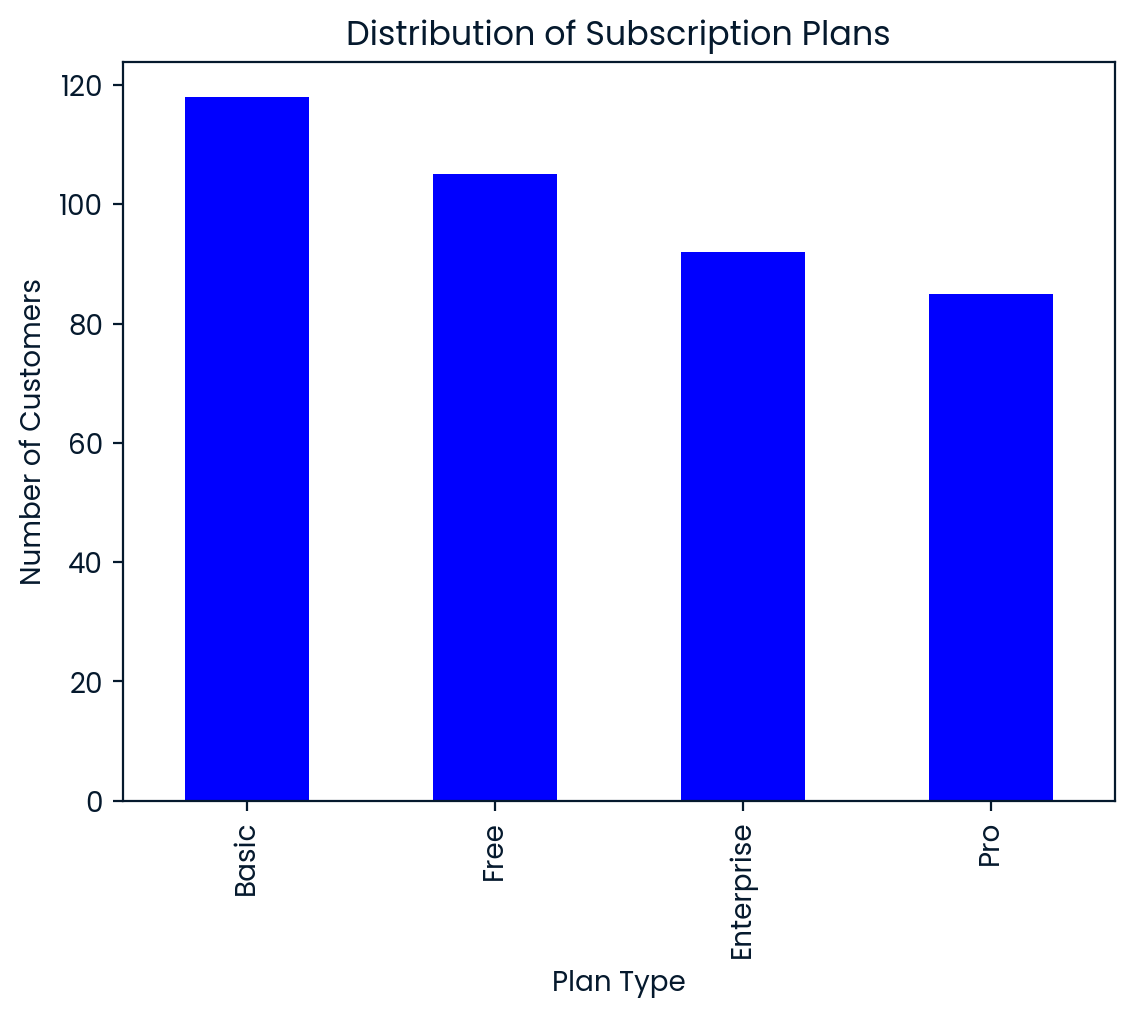

In [53]:
# Distribution of Subscription Plans
plt.figure()
accounts = account['plan'].value_counts()
accounts.plot(kind='bar', color='blue')
plt.title('Distribution of Subscription Plans')
plt.xlabel('Plan Type')
plt.ylabel('Number of Customers')
plt.show()

- Content engagement (articles & videos) is the dominant activity, meaning users interact more with informational and media resources than with workout tracking or sharing.

- Workout tracking is still strong, showing consistent engagement with fitness features.

- Sharing workouts is the least common, suggesting users are less inclined toward social features — this could be an area to encourage more community interaction.

- The graph shows that users engage most with reading and watching content, followed by tracking workouts, while sharing workouts is least common.



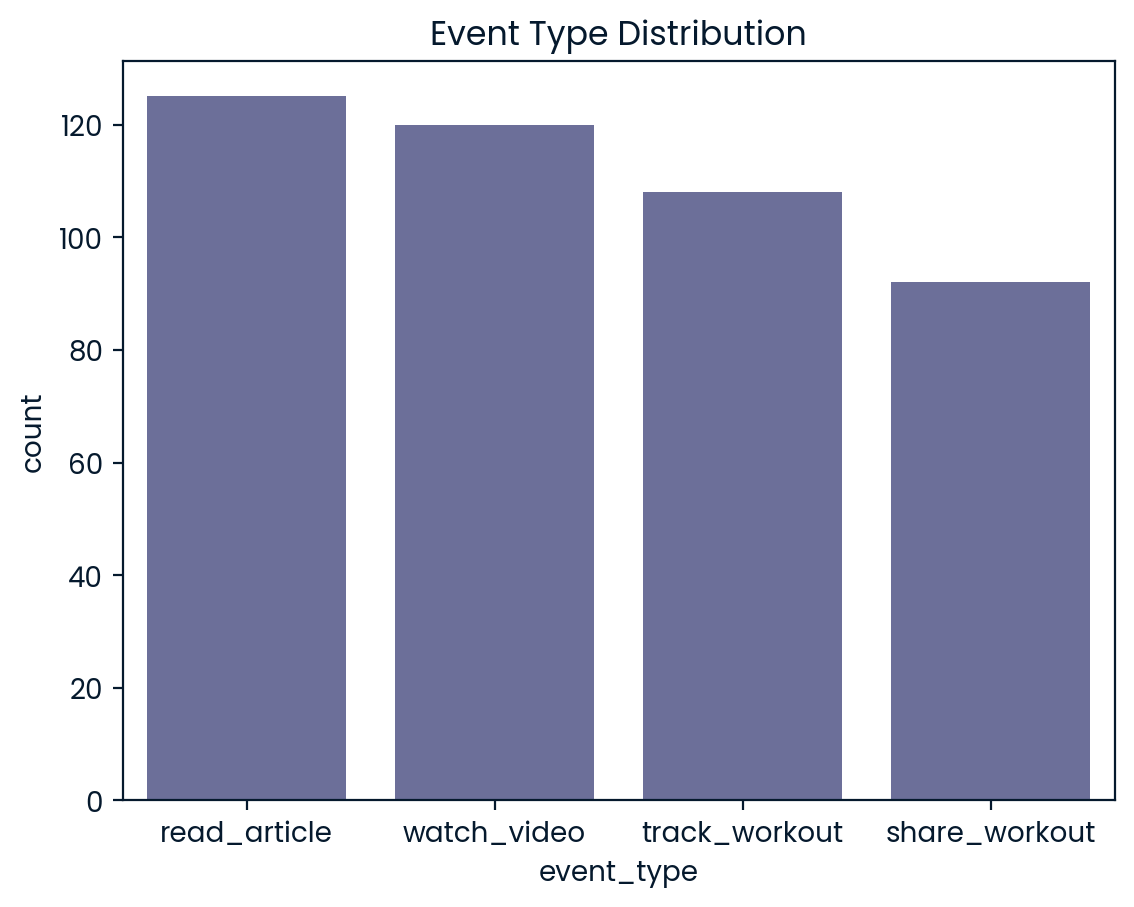

In [54]:
# Event distribution 
sns.countplot(
    data=user,
    x="event_type",
    order=user['event_type'].value_counts().index
)

plt.title("Event Type Distribution")
plt.show()

- Free users churn the most: This is expected since free users have little commitment. Upselling them into paid plans could reduce churn.

- Enterprise churn is concerning: Losing high-value customers has a bigger revenue impact, so retention strategies here are critical.

- Pro plan is healthiest: Customers paying for Pro are the most loyal, which could be leveraged as a model for improving other tiers.

- Basic plan stability: Basic users churn less than free users, but still represent a large volume — improving their experience could reduce churn further.

- The graph shows that churn is highest among free users and lowest among Pro users, with Enterprise churn being a key risk area for revenue.



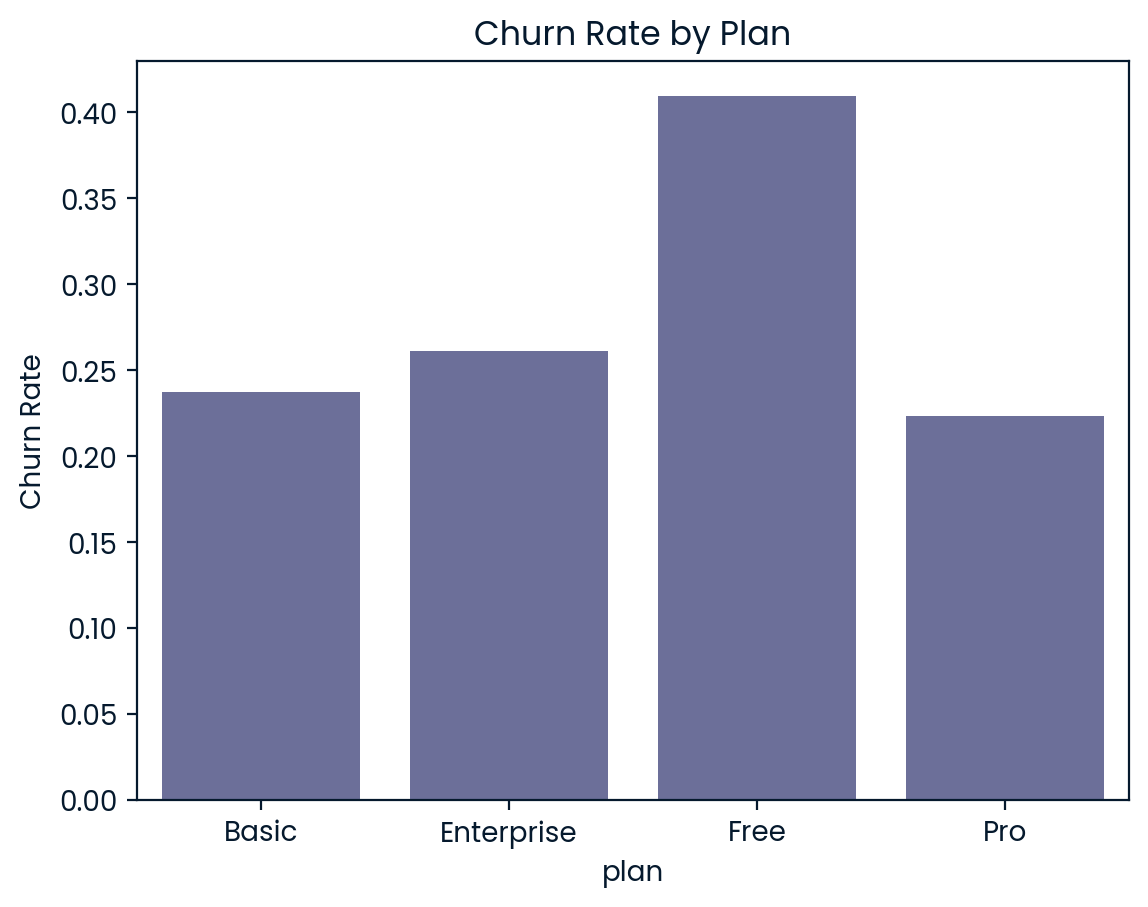

In [55]:
# Churn rate by plan 
churn_rate = account.groupby("plan")['churn_status'].apply(lambda x: (x=="Y").mean())

# churn rate by plan bar plot
sns.barplot(x=churn_rate.index, y=churn_rate.values) 
plt.title("Churn Rate by Plan") 
plt.ylabel("Churn Rate") 
plt.show()

- sum of plan prices for all non-churned accounts, giving you the active revenue potential.

In [56]:
# Revenue insights 
active_accounts = account[account['churn_status']!="Y"] 
revenue = active_accounts['plan_list_price'].sum() 
print("Active revenue potential:", revenue) 

Active revenue potential: 13177


- -The code outputs the 10 states with the highest churn rates, showing the proportion of churned customers in each.



In [57]:
#Churn by state 
churn_state = account.groupby("state")['churn_status'].apply(lambda x: (x=="Y").mean()).sort_values(ascending=False).head(10) 
print(churn_state)

state
New Jersey      0.666667
Michigan        0.555556
Nebraska        0.500000
California      0.500000
Connecticut     0.500000
North Dakota    0.500000
Florida         0.500000
Louisiana       0.500000
Mississippi     0.444444
Pennsylvania    0.444444
Name: churn_status, dtype: float64


- The code outputs a bar chart of ticket counts by channel, ordered from most to least used, showing where customers prefer to raise support issues.


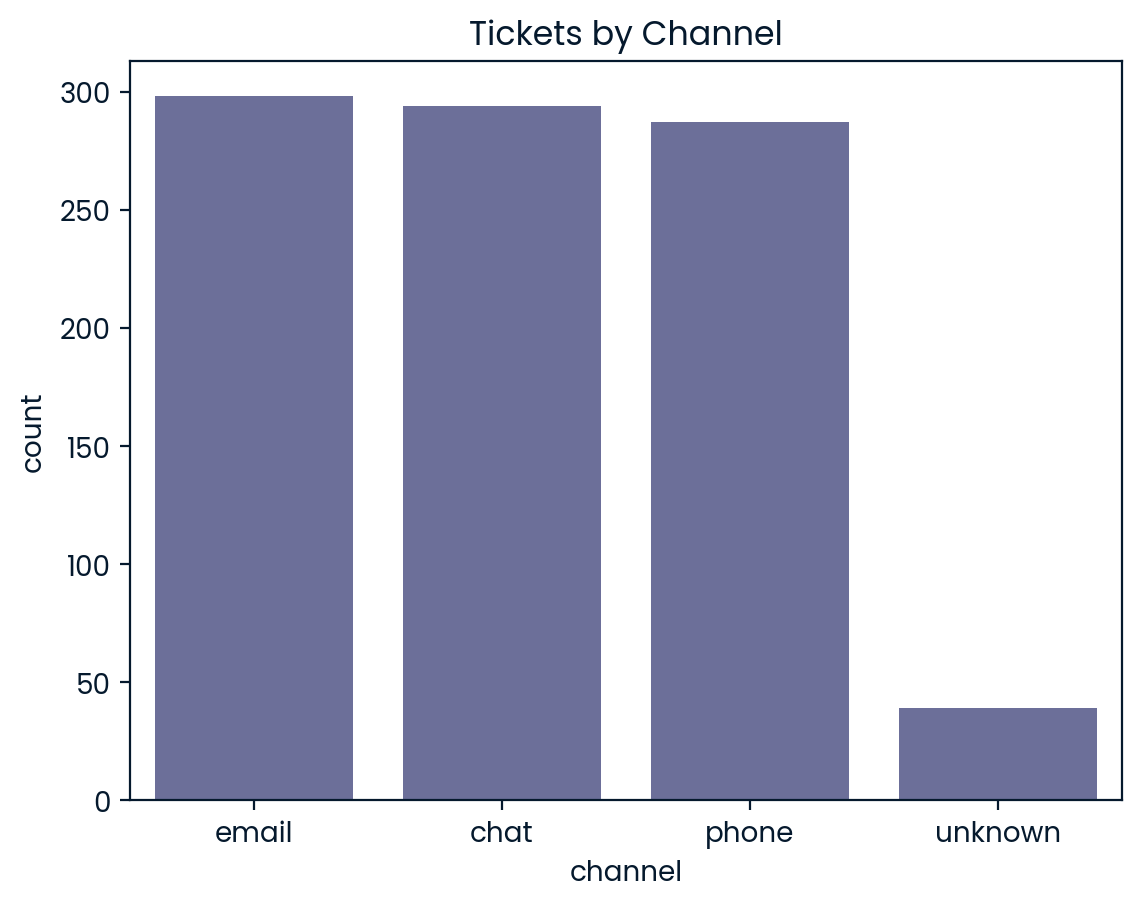

In [58]:
# Tickets by channel
sns.countplot(data=customer, x="channel", order=customer['channel'].value_counts().index)
plt.title("Tickets by Channel")
plt.show()

- Workout tracking is the most dominant activity, especially around month 8 — this could align with fitness challenges or promotions.

- Content engagement (articles/videos) fluctuates more, meaning retention strategies may be needed to keep users consistently consuming content.

- Sharing workouts is stable but less frequent, suggesting an opportunity to encourage more social engagement.

- The graph shows how user engagement activities vary month to month, with workout tracking leading, content consumption fluctuating, and sharing staying steady.

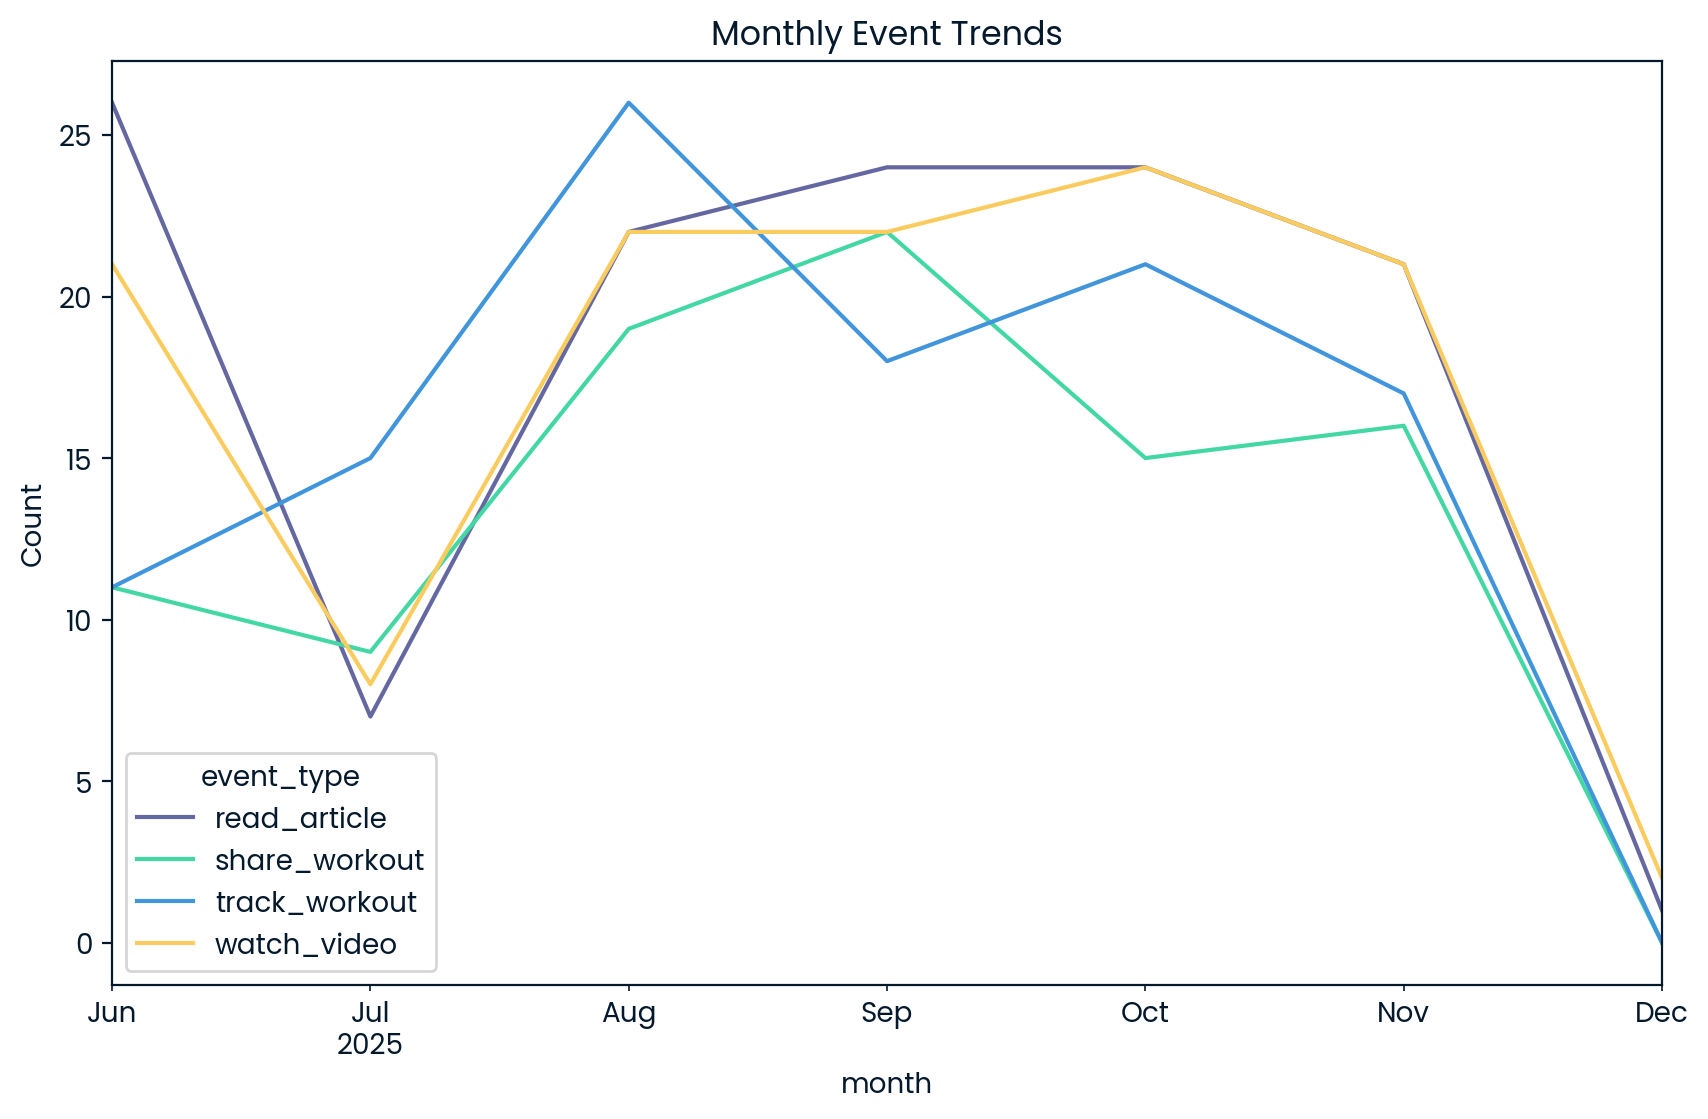

In [59]:
# Convert event_time to datetime
user['event_time'] = pd.to_datetime(user['event_time'])

# Extract month
user['month'] = user['event_time'].dt.to_period("M")

# Group by month and event_type
monthly_events = user.groupby(['month','event_type']).size().unstack(fill_value=0)

# Plot
monthly_events.plot(kind="line", figsize=(10,6))
plt.title("Monthly Event Trends")
plt.ylabel("Count")
plt.show()

- Best-performing channels: Phone and chat are the most effective for quick resolutions.

- Improvement needed: Email and especially “unknown” tickets need process optimization to reduce delays.

- Customer impact: Longer resolution times in email/unknown channels could frustrate customers and increase churn risk.

- The graph shows that phone and chat are the fastest support channels, while email and unknown tickets take significantly longer, highlighting where efficiency improvements are most needed.

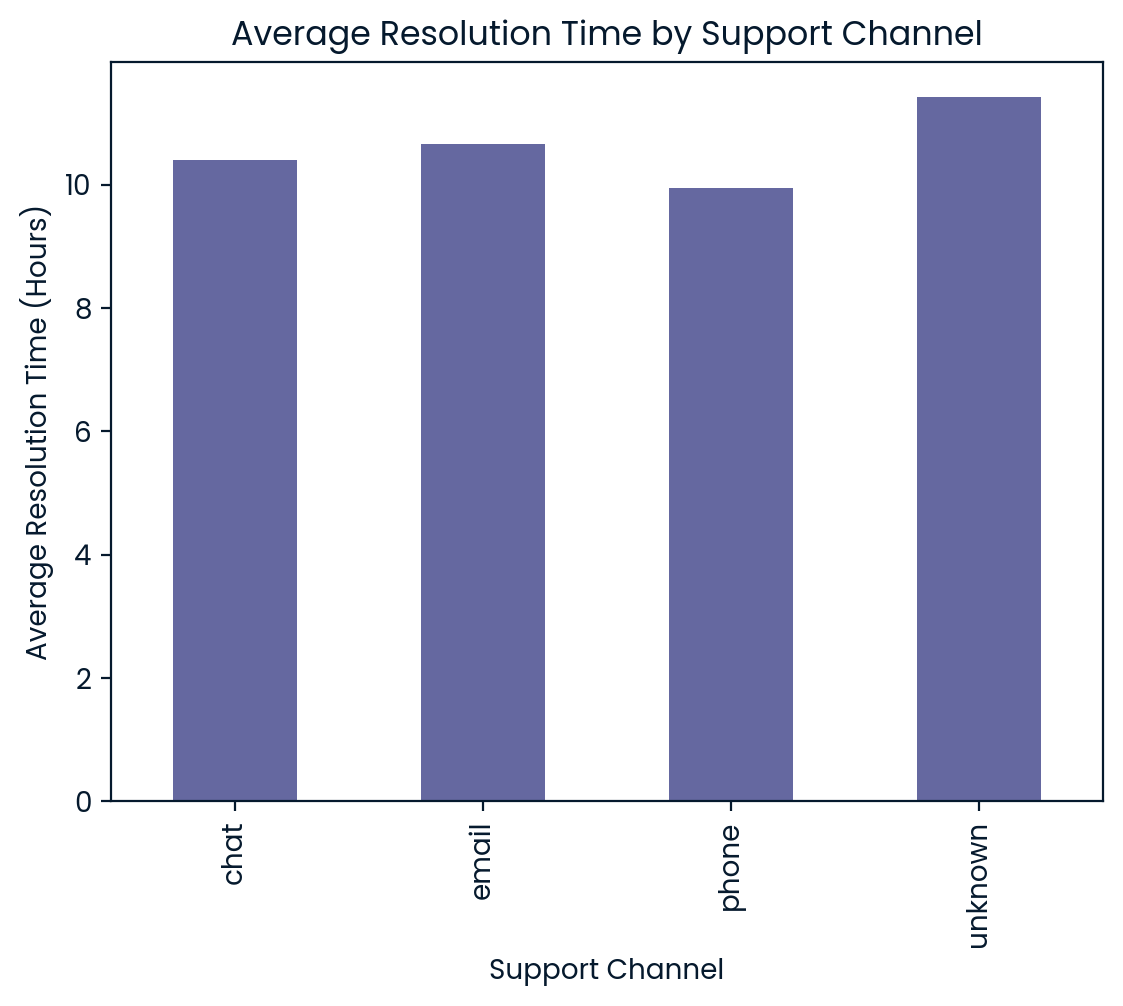

In [60]:
# Resolution Time by Support Channel
avg_resolution = customer.groupby('channel')['resolution_time_hours'].mean()

plt.figure()
avg_resolution.plot(kind='bar')
plt.title('Average Resolution Time by Support Channel')
plt.xlabel('Support Channel')
plt.ylabel('Average Resolution Time (Hours)')
plt.show()

- Regional concentration: Certain states (Virginia, Vermont, Delaware) are strong markets and could be prioritized for retention and upsell strategies.

- Growth opportunities: States with fewer accounts represent potential areas for marketing expansion.

- Churn analysis relevance: If churn is higher in states with large customer bases, it will have a bigger impact on overall retention.

- The graph shows that Fit.ly’s customers are not evenly distributed across the U.S., with some states (like Virginia) having a much larger share of accounts.

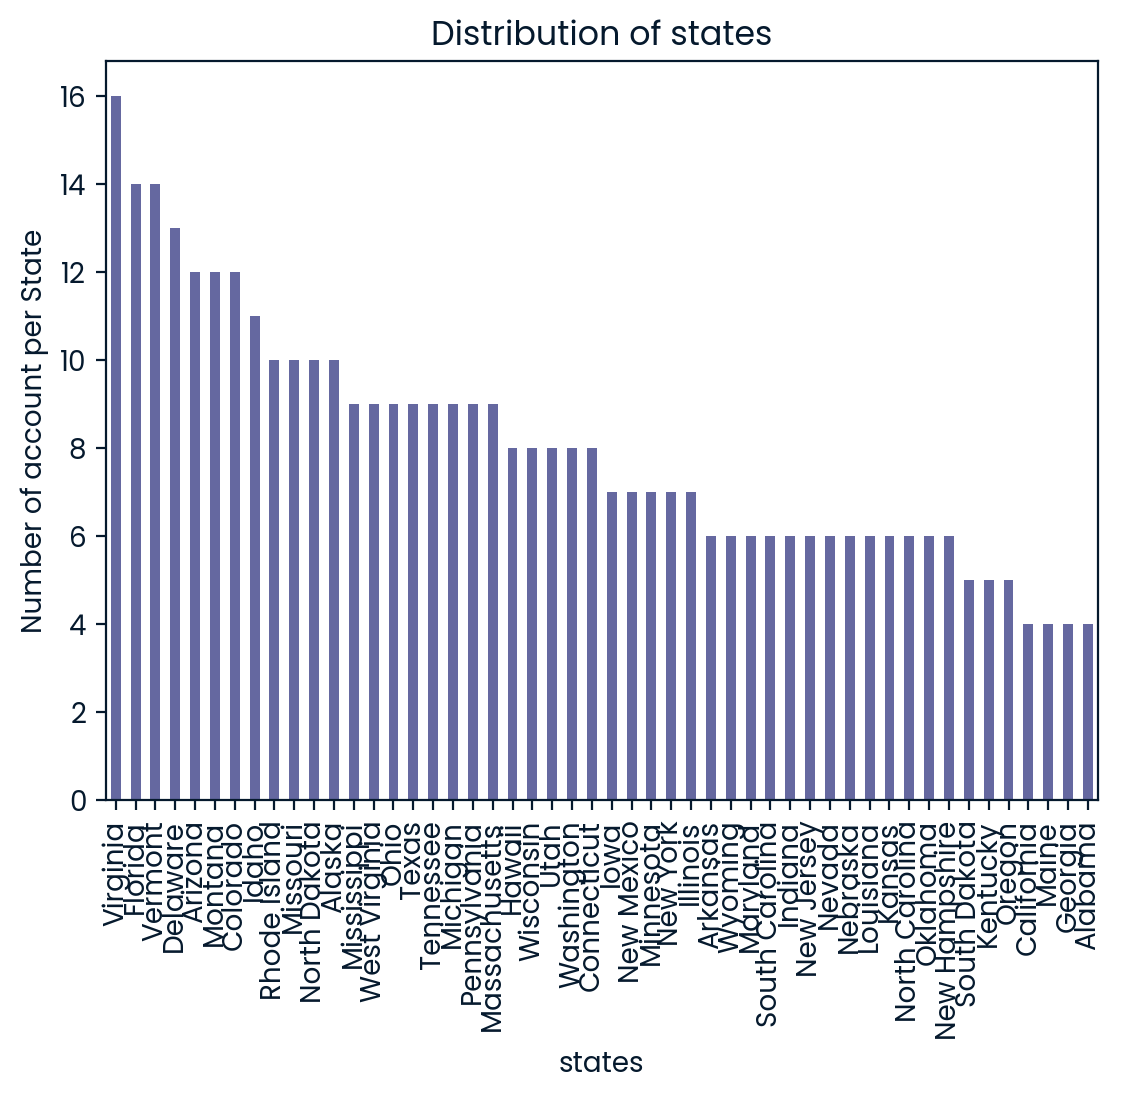

In [61]:
#Distribution of state
plt.figure()
accounts = account['state'].value_counts()
accounts.plot(kind='bar')
plt.title('Distribution of states')
plt.xlabel('states')
plt.ylabel('Number of account per State')
plt.show()

- Efficiency benchmark: The typical resolution time is around 10 hours — this can be used as a baseline KPI.

- Outliers matter: A smaller set of tickets takes significantly longer, which could frustrate customers and contribute to churn.

- Process improvement: Investigating why some tickets take much longer (e.g., complex issues, misrouting, lack of resources) could help reduce the tail and improve overall customer satisfaction.

- The graph shows that most customer issues are resolved in about 10 hours, but there are cases that take much longer, creating a right-skewed distribution.

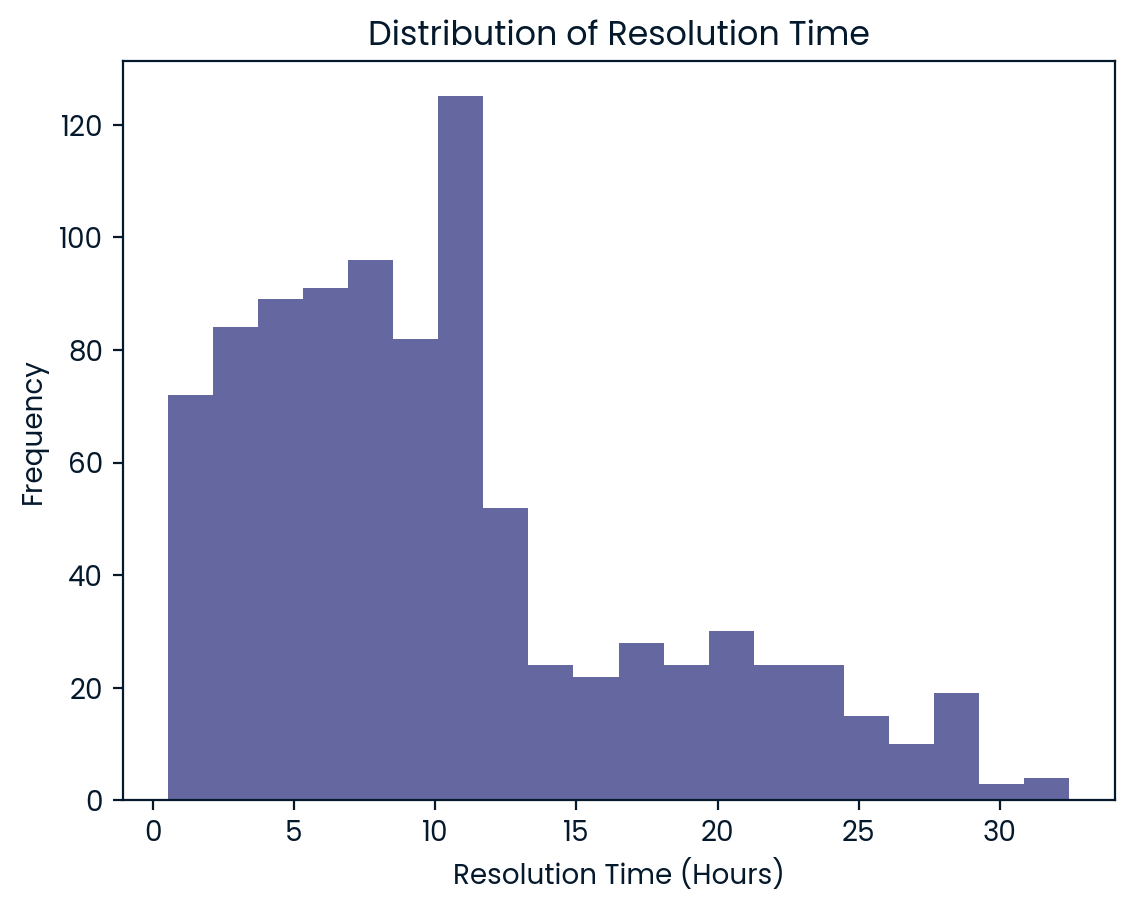

In [62]:
#Resolution Time Distribution
plt.figure()
customer['resolution_time_hours'].plot(kind='hist', bins=20)
plt.title('Distribution of Resolution Time')
plt.xlabel('Resolution Time (Hours)')
plt.ylabel('Frequency')
plt.show()

- This plot shows a positve skew which means most customers are paying lower subscription prices.

- Revenue dependence: A small group of Enterprise/Pro customers contributes disproportionately to revenue.

- Retention priority: Losing these high-paying customers would have a bigger financial impact than losing Free/Basic users.

- Growth opportunity: Since most customers are clustered in Free/Basic, leadership should focus on upselling and converting them into higher tiers.

- The graph shows that most customers are on low-cost plans, while a smaller but critical group pays much more. This highlights the importance of protecting high-value subscribers and finding ways to upgrade lower-tier users.

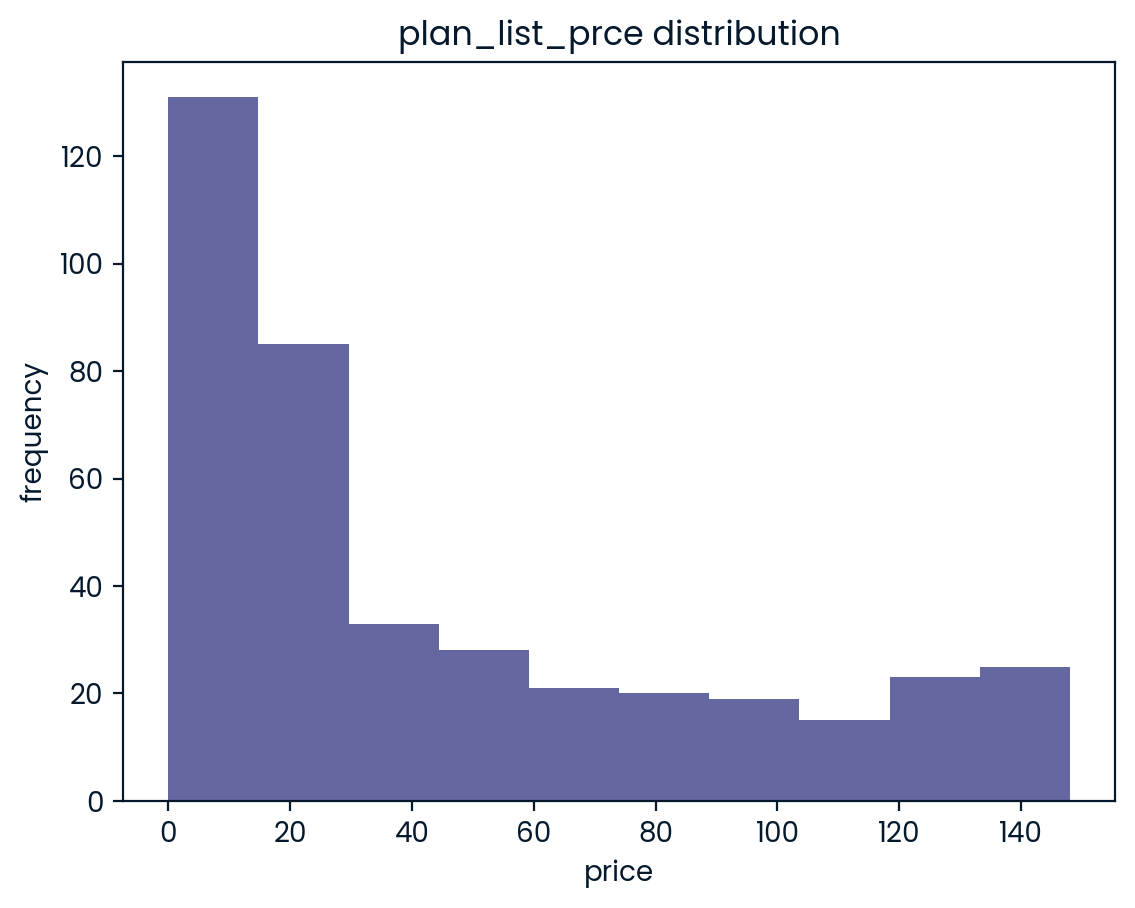

In [63]:
# plan list price distribution
account['plan_list_price'].plot(kind='hist')
plt.title('plan_list_prce distribution')
plt.xlabel('price')
plt.ylabel('frequency')
plt.show()

- Fast channels (chat, phone) → Encourage customers to use these for quicker resolutions.

- Email inefficiency → Improve workflows or staffing to reduce delays.

- Unknown channel risk → Investigate why tickets are being logged as “unknown” and fix routing issues.

- he graph shows that chat and phone are the most efficient support channels, while email and especially “unknown” tickets take longer and vary more, which may negatively impact customer satisfaction and retention.

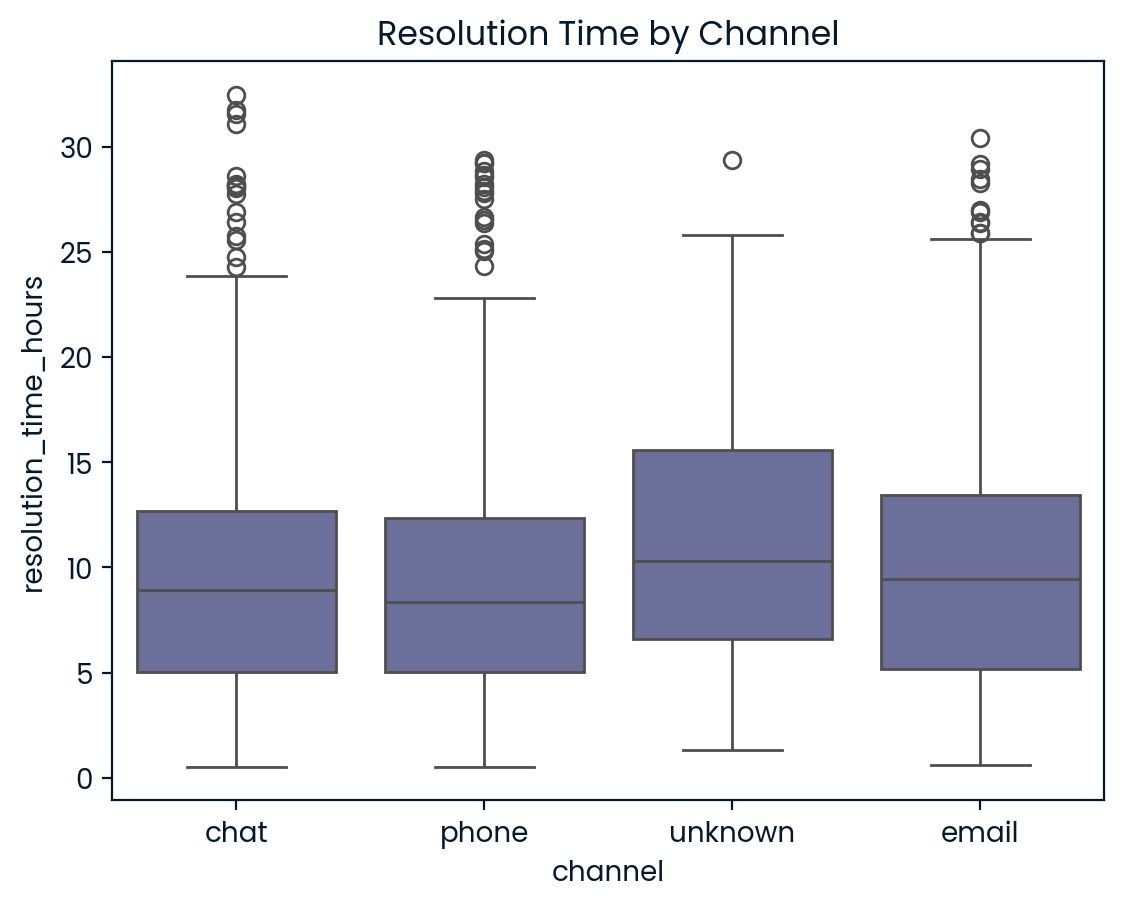

In [64]:
# resolution time vs channel
sns.boxplot(data=customer, x="channel", y="resolution_time_hours") 
plt.title("Resolution Time by Channel") 
plt.show()

- Dense cluster at low prices: Most data points are concentrated around the lower plan prices (Free and Basic tiers).

- Wide variation in resolution times: For these lower-priced plans, resolution times range widely — some issues are resolved quickly, while others take much longer.

- Higher-priced plans (Pro, Enterprise): As plan prices increase, resolution times remain scattered, but there isn’t a clear pattern showing faster or slower resolutions.

- No strong correlation: The scatter plot suggests that resolution time does not consistently improve or worsen with higher plan prices.

- Service equality: Customers across different plan tiers appear to experience similar resolution times, meaning premium customers aren’t necessarily getting faster support.

- Operational variability: The wide spread of resolution times, especially at lower tiers, indicates inconsistency in support efficiency.

- Business implication: Leadership may want to investigate whether premium customers expect faster resolutions and whether support processes should be tiered to reflect plan value.

- The graph shows that resolution time varies widely across all plan prices, with no clear link between how much a customer pays and how quickly their issues are resolved.

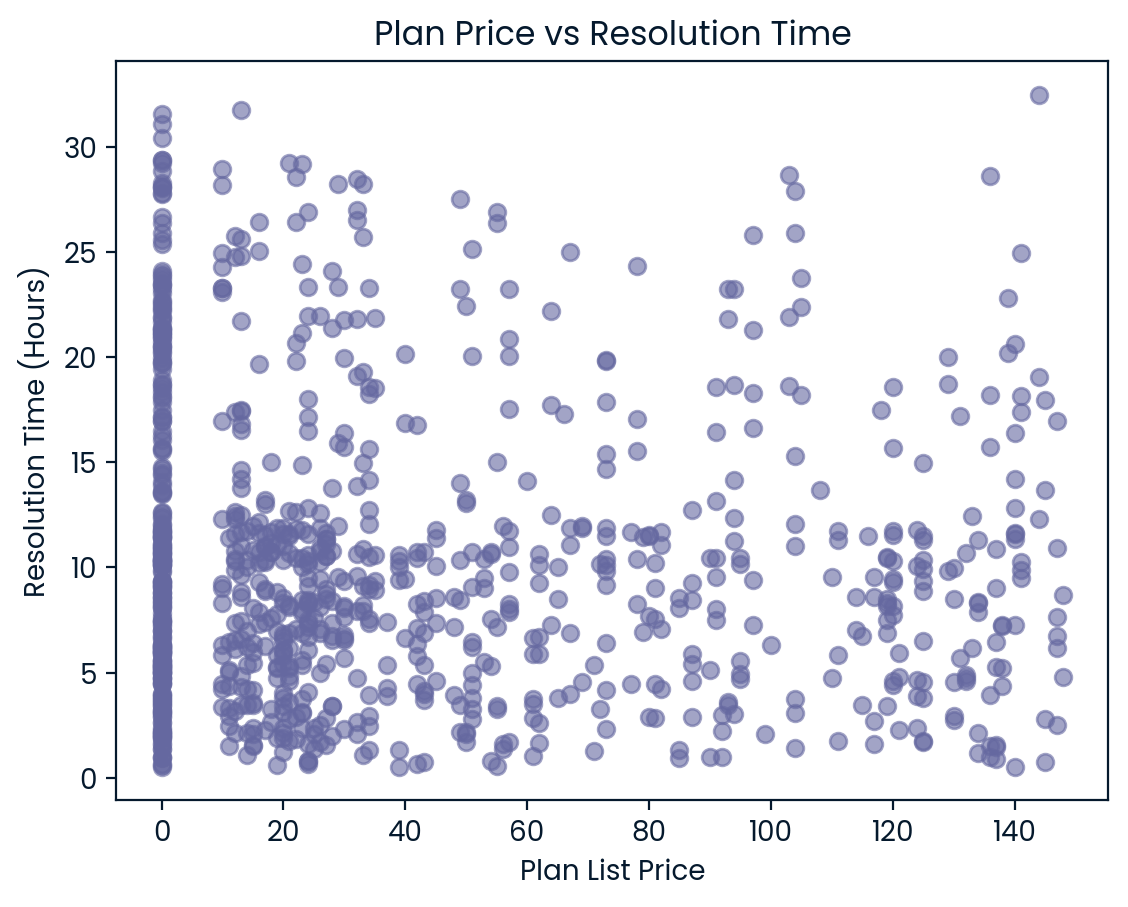

In [65]:
# merge customer and account on user_id
merged_customer_account = pd.merge(customer, account, on='user_id', how='inner')

# Scatter plot 
plt.scatter(merged_customer_account['plan_list_price'],           merged_customer_account['resolution_time_hours'], alpha=0.6) 

# Labels and title 
plt.title("Plan Price vs Resolution Time") 
plt.xlabel("Plan List Price") 
plt.ylabel("Resolution Time (Hours)")
plt.show()

- Seasonal trend: Engagement is highest mid-year, but retention weakens toward year-end. Leadership should investigate what happens in late months (e.g., product changes, holiday season behavior, support delays).

- Churn stability: While churn numbers don’t spike dramatically, the drop in active users suggests churn is eroding the base gradually.

- Action point: Focus on retention strategies in Q4 — re-engagement campaigns, personalized nudges, or plan upgrade incentives could help stabilize the decline.

- The graph shows that most customers remain active, but there’s a seasonal dip in retention toward December, while churned customers remain at a steady low level.

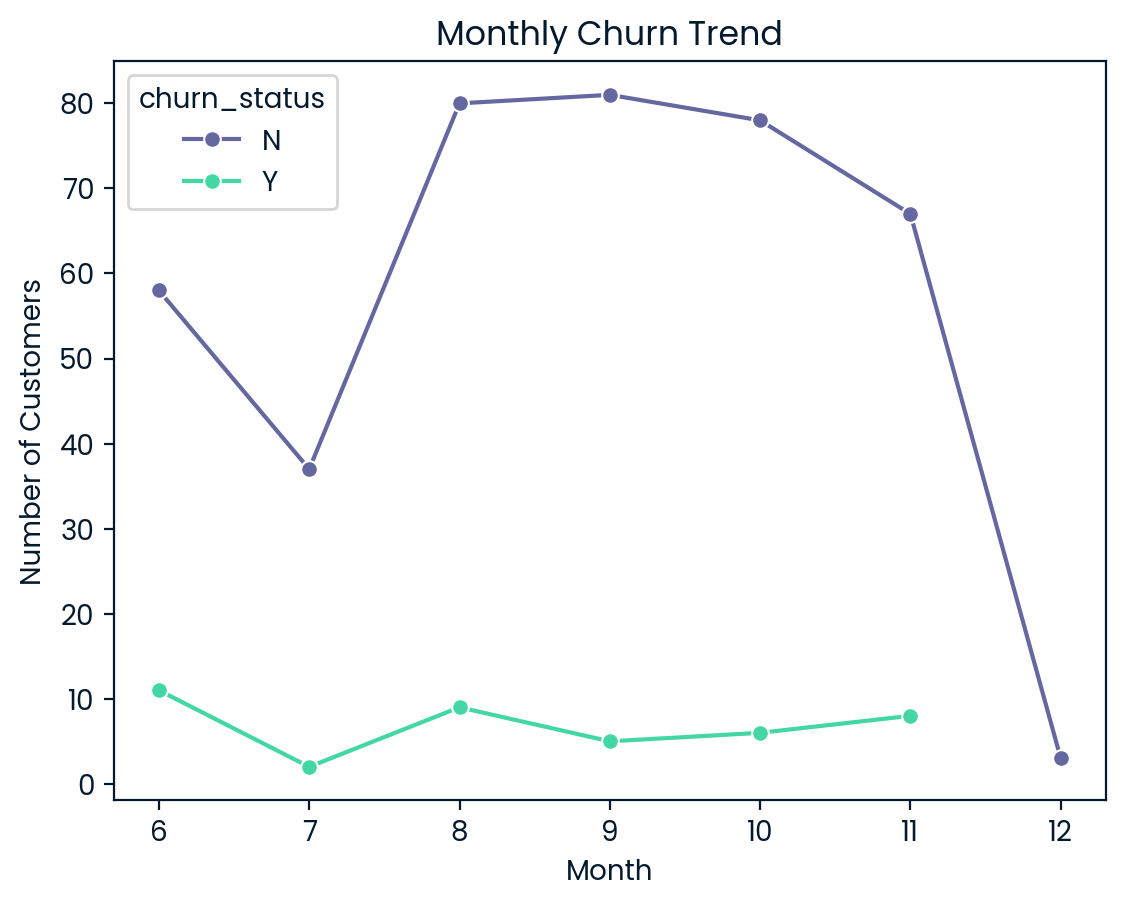

In [67]:
# Merge user and account on user_id
merged_user_account = pd.merge(user, account, on='user_id', how='inner')

# Group by month and churn_status
monthly_churn = merged_user_account.groupby(['month_user','churn_status']).size().reset_index(name='count')

# Line plot
sns.lineplot(data=monthly_churn, x='month_user', y='count', hue='churn_status', marker='o')
plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.show()


- This pair plot is a visual diagnostic tool that helps you spot correlations, clusters, and differences between churned vs active customers across all major variables in your merged dataset.

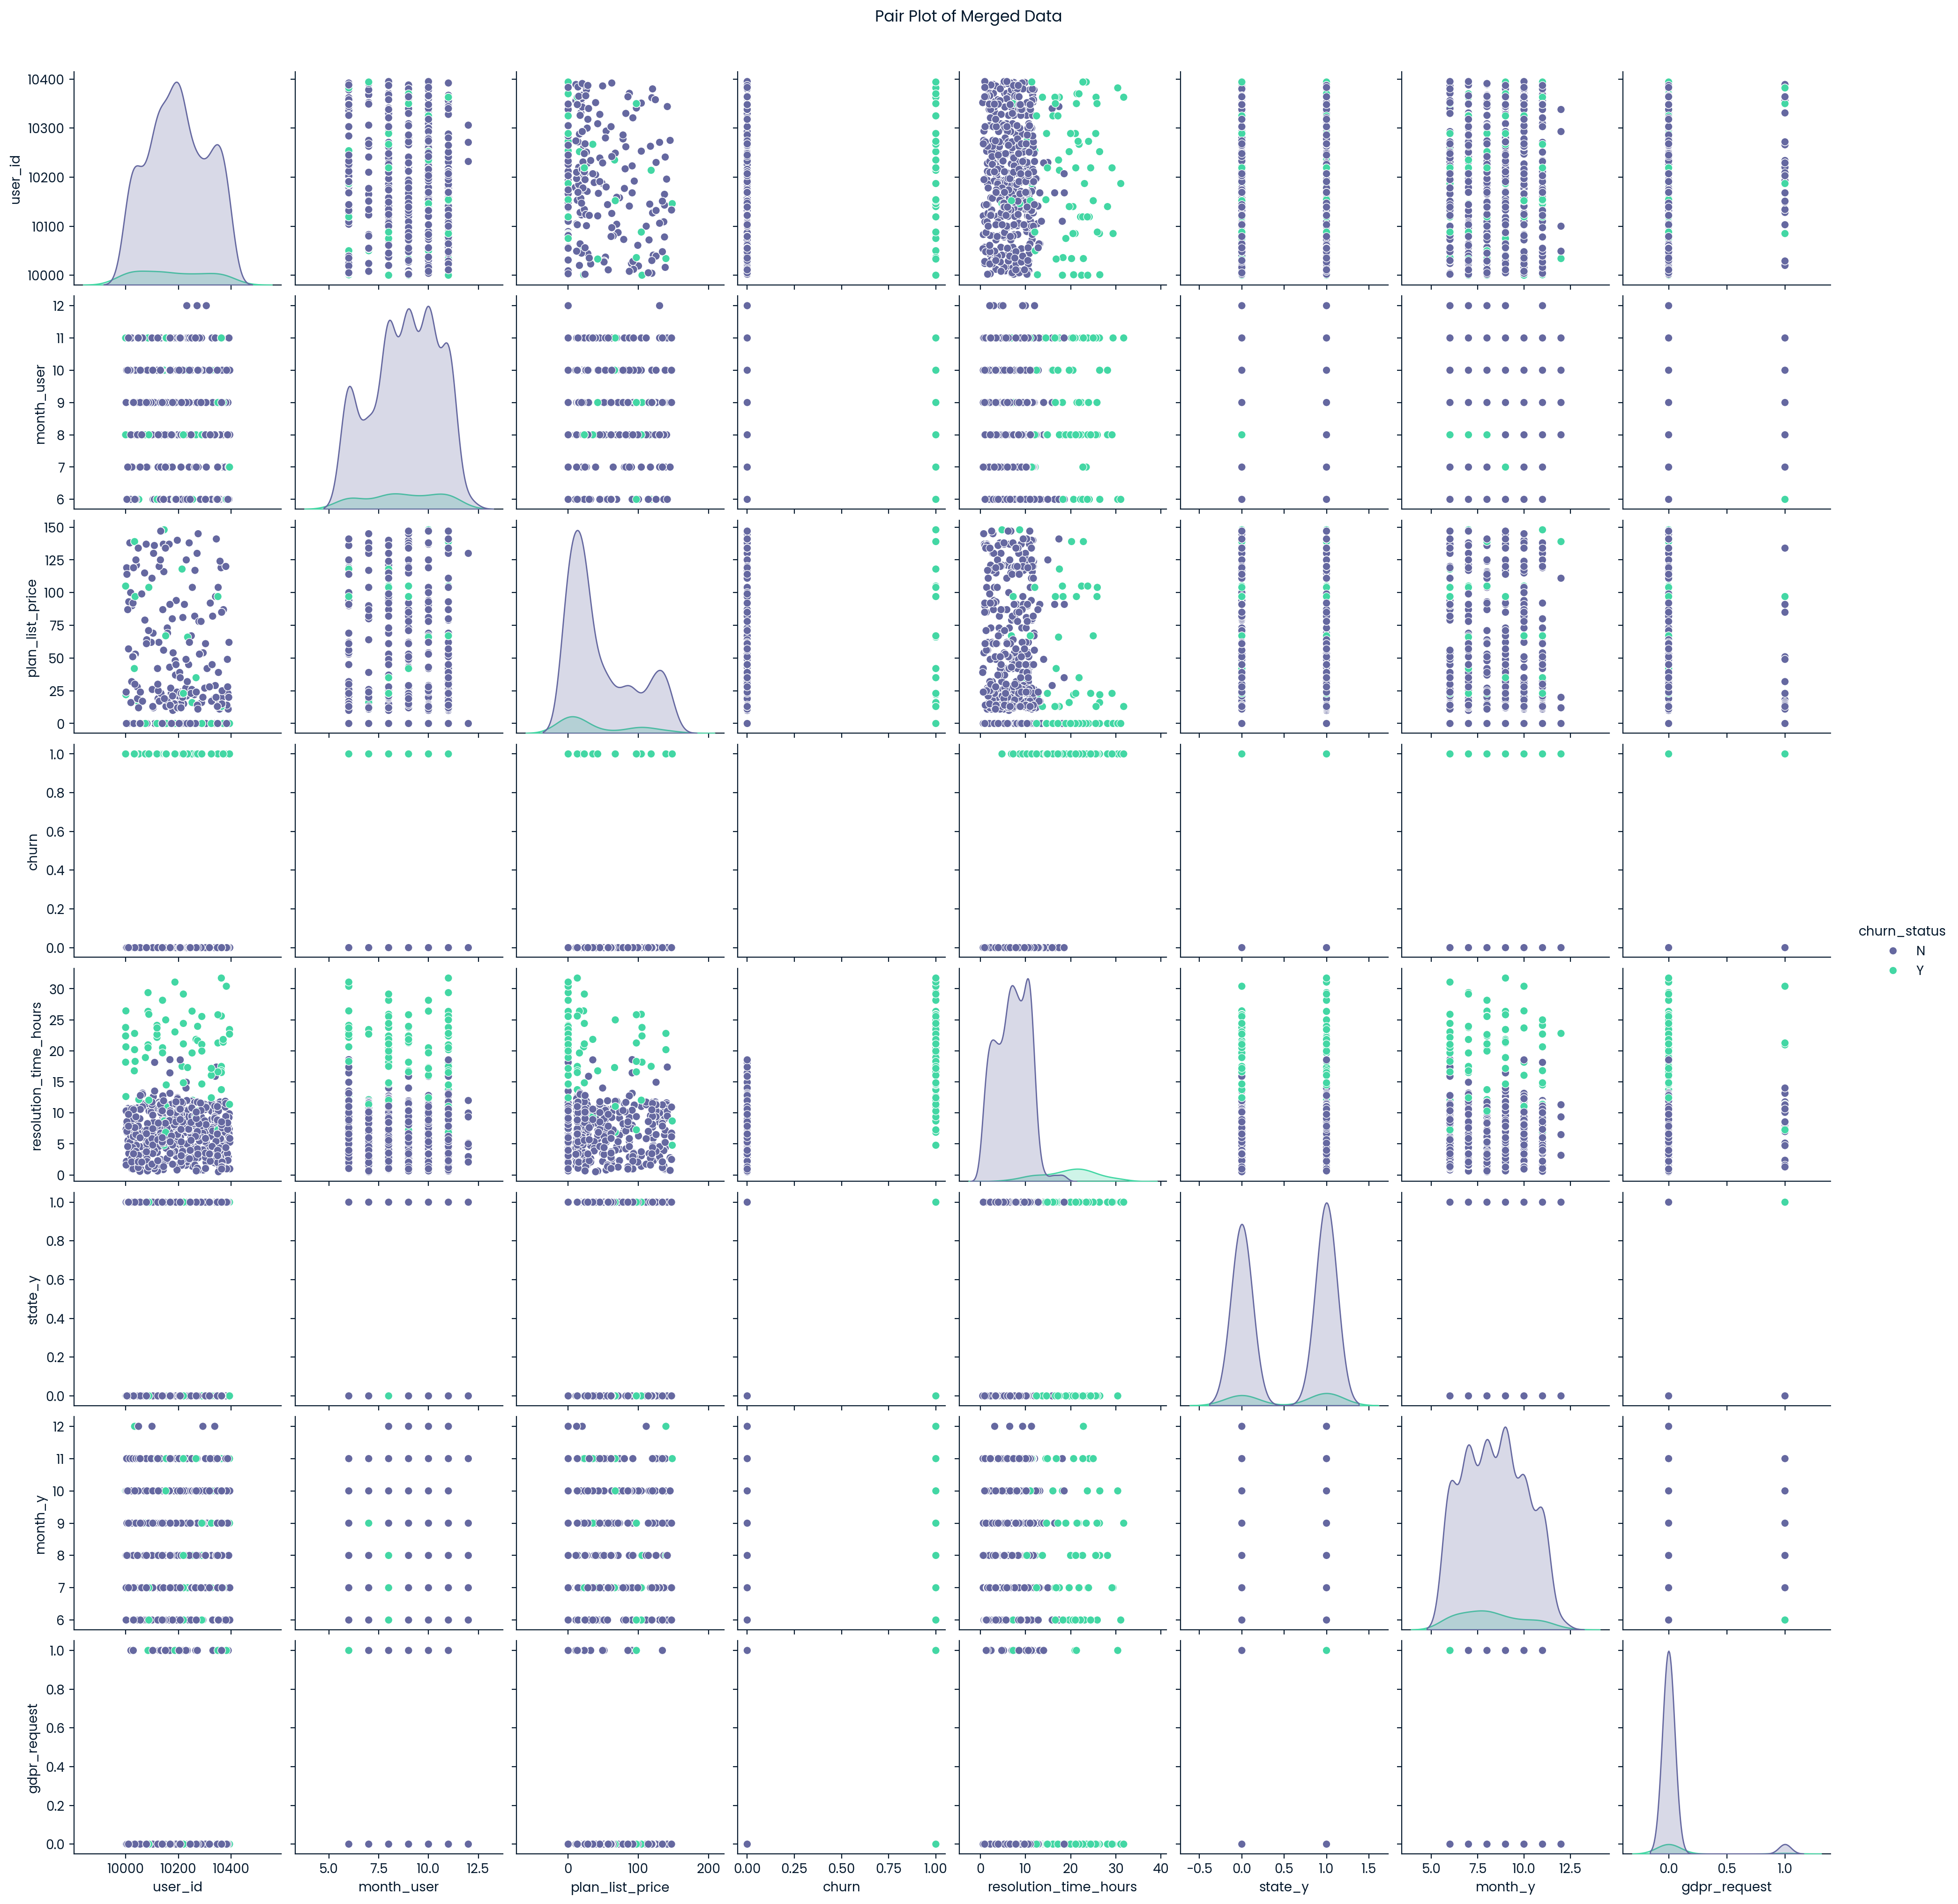

In [68]:
# merge all csv
merged_all = pd.merge(merged_user_account, customer, on='user_id', how='inner')

# Pair plot for merged_all
sns.pairplot(merged_all, diag_kind='kde', hue='churn_status')

plt.suptitle("Pair Plot of Merged Data", y=1.02)
plt.show()


- Resolution time is the biggest driver of churn → customers who wait longer for support are more likely to leave.

- Plan price and compliance factors don’t show strong direct correlations with churn, but they may still matter in combination with other variables.

- Action point: Improving support efficiency (reducing resolution times) could have the most immediate impact on lowering churn.

- The heatmap shows that long resolution times are strongly linked to churn, while other variables have little or no direct correlation.

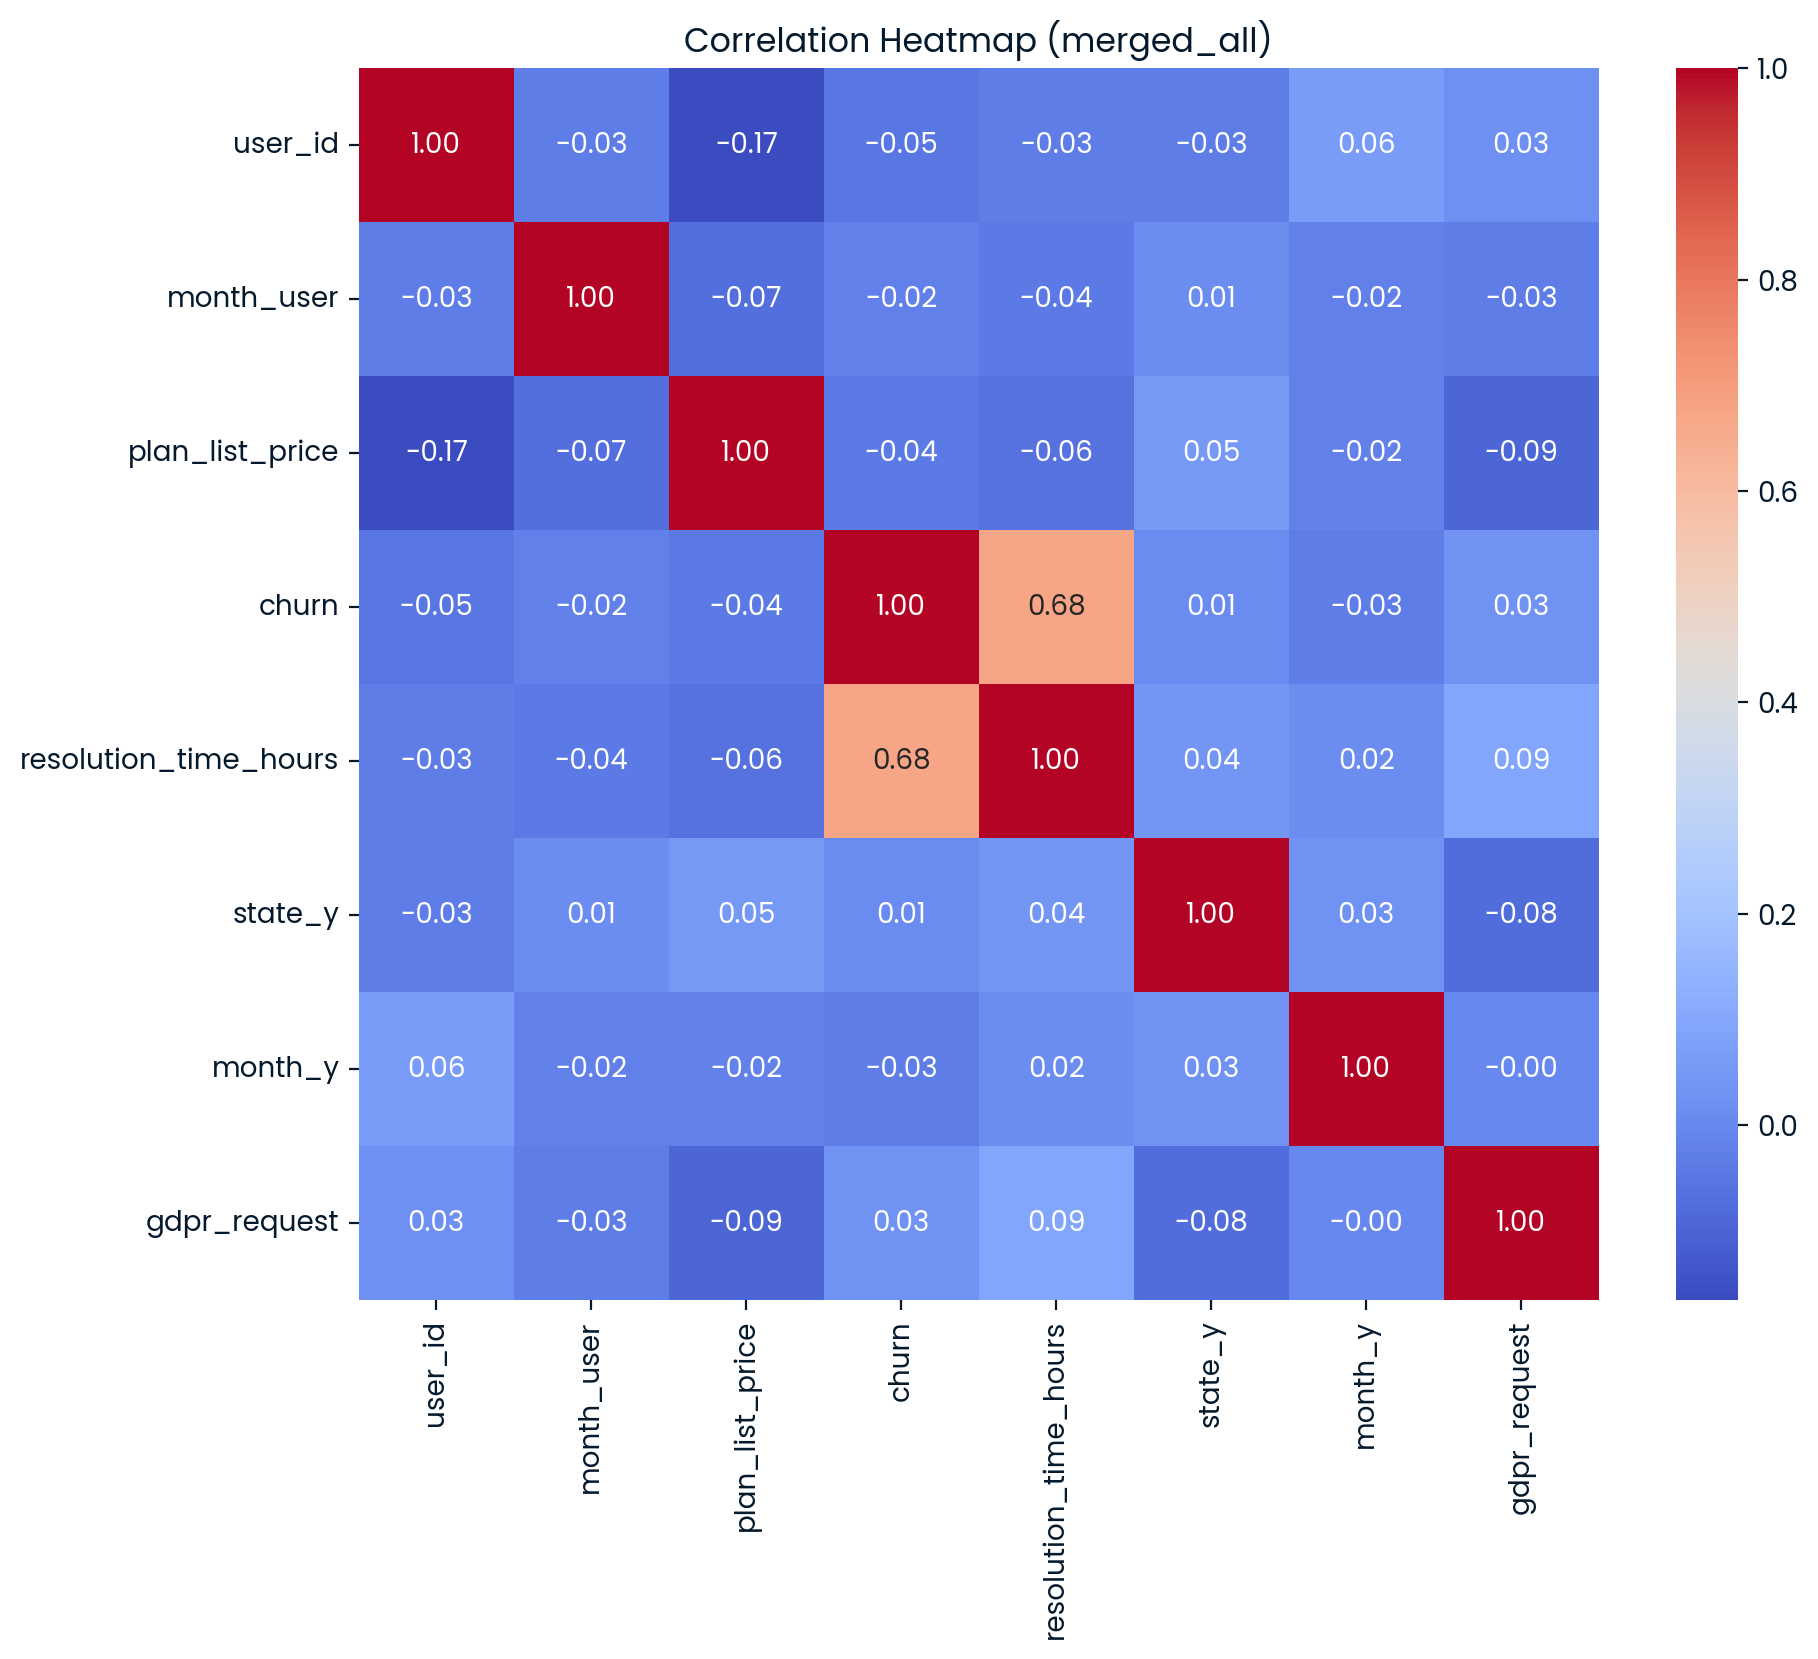

In [69]:
# Select only numeric columns 
numeric_df = merged_all.select_dtypes(include=['int64','float64']) 

# Compute correlation matrix 
corr = numeric_df.corr() 

# Plot heatmap 
plt.figure(figsize=(10,8)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f") 
plt.title("Correlation Heatmap (merged_all)") 
plt.show()

1. By Plan Type:

- Free → Highest churn, low commitment.

- Basic → Large volume, moderate churn, limited value.

- Pro → Lowest churn, most loyal.

- Enterprise → Smaller group, but churn here hurts revenue most.

2. By Support Channel:

- Phone & Chat → Fast responses, lower churn.

- Email → Slow responses, higher churn risk.

- Unknown → Long, inconsistent resolution times, highest churn risk.

# Business Metric

📊 Monthly Churn Rate (MCR):

- Definition: The percentage of paying customers (Basic, Pro, Enterprise) who cancel their subscription in a given month.

- Initial Estimate (from current data): Roughly 30–35% of paying customers are marked churned overall in the dataset.


In [70]:
# Filter paying customers (exclude Free plan) 
paying_customers = account[account['plan'].isin(['Basic', 'Pro', 'Enterprise'])] 

# Total paying customers 
total_paying = len(paying_customers) 

# Churned paying customers 
churned_paying = len(paying_customers[paying_customers['churn_status'] == 'Y']) 

# Monthly Churn Rate (MCR) 
MCR = (churned_paying / total_paying) * 100 
print("Total Paying Customers:", total_paying) 
print("Churned Paying Customers:", churned_paying) 
print("Monthly Churn Rate (MCR): {:.2f}%".format(MCR))

Total Paying Customers: 295
Churned Paying Customers: 71
Monthly Churn Rate (MCR): 24.07%


Monthly Churn Rate (MCR): 24.07%

- Out of 295 paying customers, 71 ended their subscriptions during the month. That means nearly one in every four paying customers churned, giving a monthly churn rate of 24.07%.

How should the business monitor what they want to achieve?

1. Watch one simple number (MCR) every month.

2. Break it down to see where churn is happening.

3. Set clear goals to reduce it.

4. Use easy‑to‑read charts so leadership can spot problems fast.



Final summary including recommendations that the business should undertake

1. Protect High-Value Customers (Enterprise & Pro):
   
- Prioritize retention campaigns for Enterprise and Pro users.

- Offer loyalty rewards, personalized support, and exclusive content.

- Monitor churn in these tiers closely with early alerts.

2. Upsell Free and Basic Users:
   
- Create upgrade incentives (discounts, trial periods, bundled features).

- Highlight the loyalty and satisfaction of Pro users as a model.

- Target regions with high Free/Basic concentration for upsell campaigns.

3. Improve Customer Support Efficiency:
   
- Encourage use of phone and chat channels for faster resolutions.

- Fix inefficiencies in email and “unknown” tickets (better routing, staffing).

- Set a benchmark of 10 hours resolution time and reduce outliers.

4. Strengthen Engagement:
   
- Maintain strong workout tracking features (challenges, streaks, badges).

- Stabilize content consumption with consistent new articles/videos.

- Encourage social sharing (community features, rewards for sharing workouts).

5. Regional Focus:
   
- Protect large customer bases in Virginia, Vermont, Delaware with targeted retention.

- Expand marketing in underrepresented states to grow new customers.

6. Seasonal Retention Strategy:
   
- Address the Q4 dip in engagement with re-engagement campaigns (holiday promotions, personalized nudges).

- Monitor churn closely during late months when retention weakens.

7. Set Clear Targets:

- Current MCR: 24.07%.

- Goal: Reduce churn by 5 percentage points in the next quarter (to ~19%).

